<a href="https://colab.research.google.com/github/salomemoram/Analitica-de-negocios/blob/main/Cluster.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Caso de Estudio
Una entidad fiannciera (FINTECH) quiere implementar un modelo de Clustering
K-means de decisión para mejorar la preaprobación de créditos de consumo de sus solicitantes de este tipo de créditos. Para este proceso vamos a utlizar las variables:
Edad: indica el número de años que posee una perosna, o el tiempo que usted lleva en el sistema financiero.n
Ingresos: Engloba todos los ingresos que recibe una persona además si posee
salario mensual (USD).
Egresos:
Monto: (EAD)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans


<Axes: >

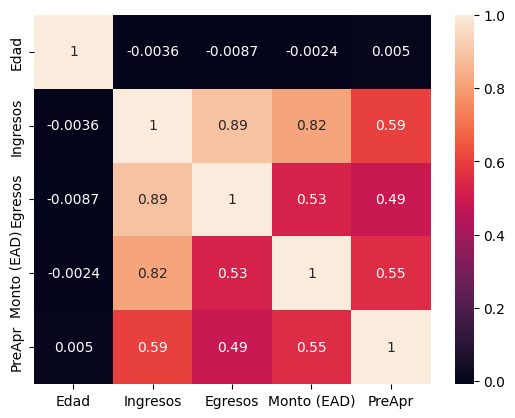

In [ ]:
nx1='/content/BASE DE DATOS.xlsx'
xdb=pd.read_excel(nx1,sheet_name=1) #Base AAA
xd=xdb.iloc[:,[1,10,11,25]] # Datos de entrada
yd=xdb.iloc[:,32]

#determianmos la correlacion entre las variables
xdb2=xdb.iloc[:,[1,10,11,25,32]]
sns.heatmap(xdb2.corr(),annot=True)

**Análisis de Resultados**

 En el heatmap se puede observar que las variables que tienen una mayor correlación entre elas son las las variables de ingresos y egresos con 89%. Esto indica que si una variable aumenta su valor, la otra tambien se incrementa (Si gano mucho, gasto mucho). Otra correlación de relevancia es la correlación entre ingresos y monto (0.82), personas con atos ingresos, piden rontos mayores (bajos ingresos-montos menores). Se destaca que la variable que tiene una mayor correlación con la variable Preapro (Salida) es la variable de ingreso (0,59)

 De acuerdo con los segmentos o clusters arrojados por el modelo, podemos observar que el Cluster 1 y crédito (2127).el Cluster 2 son los que poseen los ingresos más altos 1943 y 1378 respectivamente, clusters que igualmente son lo que tienen la menor cantidad de solicitantes de crédito con 264 y 485, Se destaca el primer Cluster, el cual agrupa a las personas con menos ingresos (242), pero es el grupo que posee la mayor cantidad de solicitantes de crédito (2127).

In [ ]:
#2. se procede con la implementacion de del modelo KMeans

np. random.seed(42) #son las semillas, el numero es el que permite generar las mismas semillas para todos (numeros aleatorios)
nc=5 #el 5, son los 5 segmentos de clientes (perfiles de clientes, 5 grupos de datos)
mkm=KMeans (n_clusters=nc, random_state=42)
mkm.fit(xd,yd) #El modelo busca la mejor relación entre la entrada y la salida
#obtenemos las caracteristicas de cada grupo
#Representa los perfiles de las perosnas mlm. cluster_ que encontró en el modelo
Tabla=pd.DataFrame (mkm. cluster_centers_, columns=xd. columns)
display (Tabla)

#Para saber los porcentajes de PreApro o PreNeg por segmento sucursal o perfil
ydp=mkm.labels_ #esto me indica como queda clasificado cada datos
ndc=np.bincount(ydp) #esto me indica cuantos datos quedan por segmento
print('El numero de datos por cluster es:', ndc)

,Edad,Ingresos,Egresos,Monto (EAD)
0,41.062353,242.798352,213.255141,175.381339
1,40.814394,1943.037897,2034.368232,1151.374380
2,40.842975,1378.277280,825.976626,1500.438821
3,40.995816,1173.957912,1239.367737,656.163350
4,41.129177,711.127537,601.939361,537.170724


El numero de datos por cluster es: [2127  264  485  960 2006]


In [ ]:
# Porcentajes PreAprobación
xdb2['Cluster']=ydp
display(xdb2)

# Determinar el numero de preaprobados y prenegados
napr=xdb2.groupby('Cluster').agg({'PreApr':lambda x: (x==1).sum()})
nprn=xdb2.groupby('Cluster').agg({'PreApr':lambda x: (x==0).sum()})

#Para que la decisión sea en porcentaje
napr2=napr/(napr+nprn);nprn2=nprn/(napr+nprn)
df2=pd.DataFrame(np.column_stack((napr,nprn)),columns=['PreAprobados','PreNegados'])
display(df2)

/tmp/ipython-input-779/2914312125.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  xdb2['Cluster']=ydp


,Edad,Ingresos,Egresos,Monto (EAD),PreApr,Cluster
0,38,1356.14400,1685.622667,625.562230,1,3
1,51,286.01600,364.462000,140.031984,1,0
2,37,517.46325,629.208889,284.564492,0,4
3,29,473.27000,551.616889,309.647588,1,4
4,42,750.09175,806.715778,500.663578,1,4
...,...,...,...,...,...,...
5837,48,1207.84800,753.801111,748.041791,1,3
5838,31,1472.77200,953.812889,870.793819,1,3
5839,38,773.01975,672.910667,594.947894,1,4
5840,43,635.50175,780.691556,305.580539,1,4


,PreAprobados,PreNegados
0,292,1835
1,254,10
2,472,13
3,742,218
4,1123,883


In [ ]:
#4. Que pasa si aparece una nueva persona?

import warnings
warnings. filterwarnings ('ignore')# para que s
nueva_persona=np. array([30,500,200, 150])
ydp=mkm.predict(nueva_persona.reshape(1,-1)) #reshape: quitarle la estructura
ncl=ydp[0] # esto indica el cluster al que pertenece una persona
print("La nueva persona pertenece al cluster:", ydp)
print("El porcentaje de preaprobación para la nueva persona es:",napr2.iloc [ncl])
print("El porcentaje de prenegación para la nueva persona es:",nprn2. iloc [ncl])

La nueva persona pertenece al cluster: [0]
El porcentaje de preaprobación para la nueva persona es: PreApr    0.137283
Name: 0, dtype: float64
El porcentaje de prenegación para la nueva persona es: PreApr    0.862717
Name: 0, dtype: float64


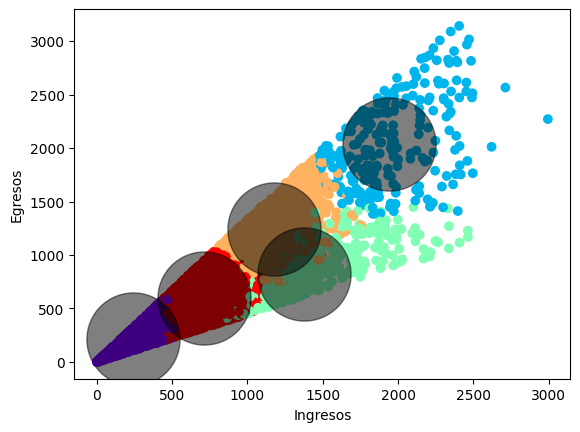

In [ ]:
#5. se procede a hacer la grafica de lo s clusters on ingesos y egresos

centers=mkm. cluster_centers_
ing=np. array(xd. iloc[:,1]); egr=np. array (xd.iloc[:,2])
plt.figure()
plt.scatter(ing, egr, c=mkm. labels_, cmap='rainbow') # Use mkn, labels_ for all data points
plt.scatter(centers [:,1], centers [:,2], c='black', s=4500, alpha=0.5)
plt.xlabel("Ingresos")
plt.ylabel("Egresos")
plt.show()

#add number to the centers
for i, center in enumerate(centers):
  plt.text(center[1], center[2])